# Data learning curve — best surrogate & oracle from the architectural sweep

How does **test** peak-MAE improve as the **training set grows**, for the two winners of the
architectural sweep? Each model keeps its own role-specific embedding **and** its own fixed
train/val/test split (`dual_splits.csv`) — we **do not touch the split**; we only resize the
**training subset** drawn from that fixed train pool and re-evaluate on the fixed val/test sets.

| role | winner | embedding | split |
|------|--------|-----------|-------|
| **surrogate** | `cnn-max-d1` | ESM-2 (1280-d) | `surrogate_role` |
| **oracle** | `cnn-max-d2` | ProstT5 (1024-d) | `oracle_role` |

- Training-data fractions: **10% / 20% / 50% / 80% / 100%** of each role's fixed train pool.
- Each train-size point is averaged over **3 random subset draws** (seeds 0–2) → mean ± std bands.
- Same protocol as the sweep: targets standardized on each train subset, standardized-peak MSE,
  Adam(1e-3, wd 1e-4), batch 32, **early stopping on the fixed val set** (max 100 epochs, patience 10,
  best weights restored). Reuses `sweep_peak_oracle.train_eval` so fits match the sweep exactly.

## 0. Setup — both role embeddings + their fixed splits (surrogate ESM-2, oracle ProstT5)

In [1]:
import csv, os, json, numpy as np, torch
import peak_models as pm
import sweep_peak_oracle as swp                                   # reuse the sweep's role loaders + train_eval
try:
    import arcadia_pycolor as apc; apc.mpl.setup(); HAVE_APC=True
except Exception: HAVE_APC=False
import matplotlib.pyplot as plt
def C(k): return getattr(apc,k) if HAVE_APC else {"aegean":"#2b6c8f","amber":"#f6a200","rose":"#c5474b","seaweed":"#3b8a6e","gray":"#888","black":"#000"}.get(k,"#333")
dev=swp.device()

# the two winners of the architectural sweep, each on its own role embedding + fixed split
BEST={"surrogate":{"arch":"cnn","pool":"max","n_conv":1,"depth":1},
      "oracle":   {"arch":"cnn","pool":"max","n_conv":2,"depth":2}}
ROLE_EMB={"surrogate":"ESM-2 · cnn-max-d1","oracle":"ProstT5 · cnn-max-d2"}

# preload each role's embedding cache + fixed train/val/test split onto the GPU once
DATA={role: swp.load_data(role, dev, to_gpu=True) for role in BEST}
for role,D in DATA.items():
    print(f"{role:9} {D['emb']:8} d_in={D['d_in']} | train pool={len(D['tr'])} val={len(D['va'])} test={len(D['te'])} (val/test fixed)")

# curated rows (seq/name), row-aligned to peaks.npy — used by the model-free §3/§4 diagnostics
CUR=swp.CUR
rows=list(csv.DictReader(open(os.path.join(CUR,"peaks_assignments.csv")))); rows.sort(key=lambda r:int(r["index"]))
peaks=np.load(os.path.join(CUR,"peaks.npy")).astype(np.float32); N=len(rows)

def subset_D(D, sub):
    """Shallow copy of D with the *train* pool restricted to `sub` (val/test untouched), restandardized on it."""
    pk=D["Pk"].detach().cpu().numpy(); mean=pk[sub].mean(0); std=pk[sub].std(0)+1e-6
    D2=dict(D); D2["tr"]=np.asarray(sub)
    D2["mean"]=mean.astype(np.float32); D2["std"]=std.astype(np.float32); D2["sd"]=torch.tensor(std,device=dev)
    return D2

surrogate esm      d_in=1280 | train pool=528 val=112 test=118 (val/test fixed)
oracle    prostt5  d_in=1024 | train pool=534 val=112 test=112 (val/test fixed)


## 1. Sweep training-set size (fixed val/test, 3 subset draws per point)

In [2]:
FRACS=[0.1,0.2,0.5,0.8,1.0]; SEEDS=[0,1,2]; EPOCHS=100; PATIENCE=10
LC_CACHE="trained_models/data_learning_curve_dual.json"          # test/val MAE vs train-size, per role (fixed split)
LC_MODEL_DIR="trained_models/lc_models"; os.makedirs(LC_MODEL_DIR,exist_ok=True)  # per-fit checkpoints
def lc_model_path(role,f,sd): return f"{LC_MODEL_DIR}/{role}_{swp.label(BEST[role])}_p{int(round(f*100))}_s{sd}.pt"

if os.path.exists(LC_CACHE):
    res=json.load(open(LC_CACHE)); print(f"loaded learning-curve cache: {LC_CACHE}")
    for role in DATA:
        r=res[role]
        for i,f in enumerate(r["frac"]):
            print(f"  {role:9} {int(f*100):3d}% | n_train={r['n'][i]:4d} | test MAE {r['te_mean'][i]:5.2f} ± {r['te_std'][i]:4.2f} nm | val MAE {r['va_mean'][i]:5.2f}")
else:
    res={}
    for role,D in DATA.items():
        spec=BEST[role]; pool=D["tr"]                            # subsample ONLY the fixed train split
        print(f"--- {role}: {ROLE_EMB[role]} | train pool={len(pool)} (val/test fixed) ---", flush=True)
        r={"emb":D["emb"],"n":[],"frac":[],"te_mean":[],"te_std":[],"va_mean":[]}
        for f in FRACS:
            n=int(round(f*len(pool))); te,va=[],[]
            for sd in SEEDS:
                sub=np.random.default_rng(sd).choice(pool, n, replace=False)
                path=lc_model_path(role,f,sd)
                if os.path.exists(path):
                    ck=torch.load(path,map_location="cpu",weights_only=False); m={"test_mae":ck["test_mae"],"val_mae":ck["val_mae"]}
                else:
                    D2=subset_D(D, sub)
                    m,base=swp.train_eval(spec, sd, D2, dev, EPOCHS, PATIENCE)
                    pm.save_model(path, base, {**spec,"d_in":D["d_in"],"out":2,"seed":sd,"role":role,"emb":D["emb"],
                                               "mean":D2["mean"],"std":D2["std"],"n_train":n,**m})
                te.append(m["test_mae"]); va.append(m["val_mae"])
            r["n"].append(n); r["frac"].append(f)
            r["te_mean"].append(float(np.mean(te))); r["te_std"].append(float(np.std(te))); r["va_mean"].append(float(np.mean(va)))
            print(f"  {int(f*100):3d}% | n_train={n:4d} | test MAE {np.mean(te):5.2f} ± {np.std(te):4.2f} nm | val MAE {np.mean(va):5.2f}", flush=True)
        res[role]=r
    json.dump(res, open(LC_CACHE,"w"), indent=2)
    print(f"saved learning-curve cache: {LC_CACHE}  ({len(DATA)*len(FRACS)*len(SEEDS)} checkpoints -> {LC_MODEL_DIR}/)")

loaded learning-curve cache: trained_models/data_learning_curve_dual.json
  surrogate  10% | n_train=  53 | test MAE 29.74 ± 2.13 nm | val MAE 26.75
  surrogate  20% | n_train= 106 | test MAE 24.10 ± 0.76 nm | val MAE 20.02
  surrogate  50% | n_train= 264 | test MAE 19.94 ± 0.70 nm | val MAE 17.68
  surrogate  80% | n_train= 422 | test MAE 16.82 ± 0.15 nm | val MAE 15.99
  surrogate 100% | n_train= 528 | test MAE 15.27 ± 0.67 nm | val MAE 15.01
  oracle     10% | n_train=  53 | test MAE 21.40 ± 0.98 nm | val MAE 28.48
  oracle     20% | n_train= 107 | test MAE 21.23 ± 0.63 nm | val MAE 24.19
  oracle     50% | n_train= 267 | test MAE 15.90 ± 1.56 nm | val MAE 17.75
  oracle     80% | n_train= 427 | test MAE 12.62 ± 0.69 nm | val MAE 15.39
  oracle    100% | n_train= 534 | test MAE 12.36 ± 0.66 nm | val MAE 14.68


## 2. Learning curve

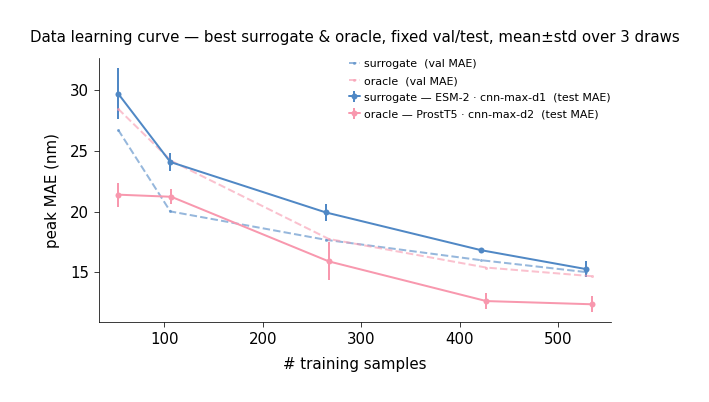

surrogate (esm): test MAE 29.7 nm @ n=53 (10%) -> 15.3 nm @ n=528 (100%)
oracle    (prostt5): test MAE 21.4 nm @ n=53 (10%) -> 12.4 nm @ n=534 (100%)


In [3]:
fig,ax=plt.subplots(figsize=(8.5,5.2))
col={"surrogate":C("aegean"),"oracle":C("rose")}
for role in DATA:
    r=res[role]; n=np.array(r["n"]); te=np.array(r["te_mean"]); sd=np.array(r["te_std"])
    ax.errorbar(n,te,yerr=sd,marker="o",capsize=3,lw=2,color=col[role],label=f"{role} — {ROLE_EMB[role]}  (test MAE)")
    ax.plot(n,r["va_mean"],ls="--",marker=".",color=col[role],alpha=0.6,label=f"{role}  (val MAE)")
ax.set_xlabel("# training samples"); ax.set_ylabel("peak MAE (nm)")
ax.set_title("Data learning curve — best surrogate & oracle, fixed val/test, mean±std over 3 draws")
ax.legend(fontsize=11)
plt.tight_layout(); fig.savefig("trained_models/learning_curve_dual.png",dpi=130,bbox_inches="tight"); plt.show()
for role in DATA:
    r=res[role]; print(f"{role:9} ({r['emb']}): test MAE {r['te_mean'][0]:.1f} nm @ n={r['n'][0]} (10%) -> {r['te_mean'][-1]:.1f} nm @ n={r['n'][-1]} (100%)")

## 3. Ruggedness — does the peak jump between near-identical sequences?

Independent of any model: among FP pairs that are sequence-similar (4-mer-cosine prefilter, then exact alignment
identity), how much does the peak `0.5(|Δex|+|Δem|)` diverge as a function of identity? A **smooth** map drives
Δpeak→0 as identity→100%; a **rugged** one keeps a fat upper tail of large Δpeak even among near-twins. The
**median at high identity** is the intrinsic floor (best any model could do); the **upper tail** is the cliff
signal that caps a smoothly-interpolating model and inflates the test-error mean.

aligning 34968 candidate pairs (4-mer cos >= 0.6) ...


saved ground-truth similarity–Δpeak cache: trained_models/similarity_deltapeak_truth.npz
FLOOR  median Δpeak at identity>=0.98: 7.5 nm (n=1369)
RUGGED identity>=0.90 (n=20471): %Δ>20nm=58%  p95=103nm  max=218nm
identity bin     n   medianΔ  p90Δ   maxΔ  %>20nm
  [0.70,0.85)    651    31.5   80.5  211.0    64%
  [0.85,0.90)  13187    31.5   74.5  217.5    64%
  [0.90,0.95)  12146    36.0   88.5  217.5    64%
  [0.95,0.98)   6956    23.5   70.8  201.5    54%
  [0.98,1.00)   1369     7.5   53.0  198.0    30%

top cliffs (id>=0.90, Δ>=30 nm; 10268 total):
  id 0.93  Δ   218  mNeptune684       (604,684) vs mTagBFP2          (399,454)
  id 0.93  Δ   216  mNeptune681       (604,681) vs mTagBFP2          (399,454)
  id 0.91  Δ   214  mNeptune684       (604,684) vs TagBFP            (402,457)
  id 0.91  Δ   213  mNeptune681       (604,681) vs TagBFP            (402,457)
  id 0.92  Δ   212  mCarmine          (603,675) vs mTagBFP2          (399,454)
  id 0.91  Δ   210  mTagBFP2          (399,454)

/tmp/ipykernel_54492/2668706665.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].set_title("Peak divergence vs identity"); ax[0].legend(fontsize=8)


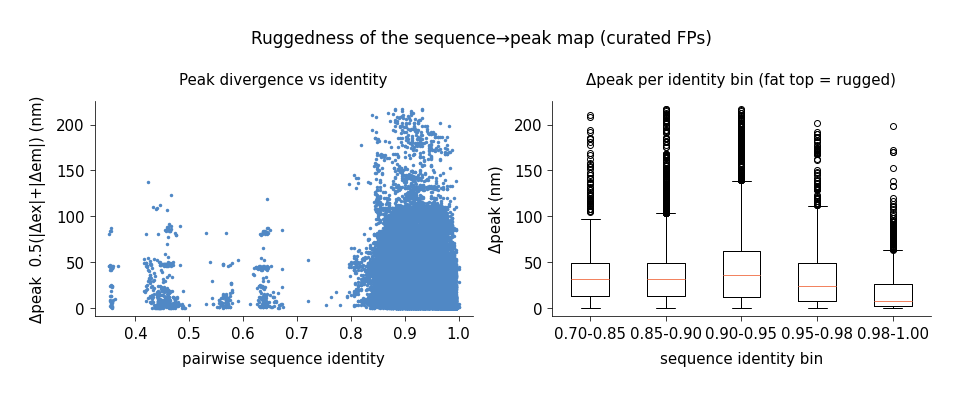

In [4]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity as cossim
import biotite.sequence as bseq, biotite.sequence.align as balign
seqsR=[r["seq"] for r in rows]; namesR=[r["name"] for r in rows]
KMER_MIN=0.6                                                     # only align reasonably-similar pairs
GT_CACHE="trained_models/similarity_deltapeak_truth.npz"         # ground-truth identity vs Δpeak (aligned pairs)
if os.path.exists(GT_CACHE):
    _z=np.load(GT_CACHE); Ai,Bi,pid,dpk,kmer=_z["Ai"],_z["Bi"],_z["pid"],_z["dpk"],_z["kmer"]
    print(f"loaded ground-truth similarity–Δpeak cache: {GT_CACHE} ({len(pid)} aligned pairs)")
else:
    Xk=CountVectorizer(analyzer="char",ngram_range=(4,4)).fit_transform(seqsR)
    Sk=cossim(Xk); np.fill_diagonal(Sk,0.0)
    iu=np.triu_indices(N,1); km=Sk[iu]; sel=np.where(km>=KMER_MIN)[0]
    Ai=iu[0][sel]; Bi=iu[1][sel]; kmer=km[sel]
    print(f"aligning {len(sel)} candidate pairs (4-mer cos >= {KMER_MIN}) ...")
    MAT=balign.SubstitutionMatrix.std_protein_matrix()
    def _ident(a,b):
        aln=balign.align_optimal(bseq.ProteinSequence(a),bseq.ProteinSequence(b),MAT,gap_penalty=(-10,-1))[0]
        return float(balign.get_sequence_identity(aln))
    pid=np.array([_ident(seqsR[a],seqsR[b]) for a,b in zip(Ai,Bi)])
    dpk=0.5*(np.abs(peaks[Ai,0]-peaks[Bi,0])+np.abs(peaks[Ai,1]-peaks[Bi,1]))
    np.savez(GT_CACHE, Ai=Ai, Bi=Bi, pid=pid, dpk=dpk, kmer=kmer)
    print(f"saved ground-truth similarity–Δpeak cache: {GT_CACHE}")

floor=np.median(dpk[pid>=0.98]); rug=pid>=0.90
print(f"FLOOR  median Δpeak at identity>=0.98: {floor:.1f} nm (n={(pid>=0.98).sum()})")
print(f"RUGGED identity>=0.90 (n={rug.sum()}): %Δ>20nm={100*np.mean(dpk[rug]>20):.0f}%  p95={np.percentile(dpk[rug],95):.0f}nm  max={dpk[rug].max():.0f}nm")
bins=[(0.70,0.85),(0.85,0.90),(0.90,0.95),(0.95,0.98),(0.98,1.001)]
print("identity bin     n   medianΔ  p90Δ   maxΔ  %>20nm")
for lo,hi in bins:
    x=dpk[(pid>=lo)&(pid<hi)]
    if len(x): print(f"  [{lo:.2f},{hi:.2f})  {len(x):5d}  {np.median(x):6.1f}  {np.percentile(x,90):5.1f}  {x.max():5.1f}  {100*np.mean(x>20):4.0f}%")
cl=np.where((pid>=0.90)&(dpk>=30))[0]; cl=cl[np.argsort(-dpk[cl])][:12]
print(f"\ntop cliffs (id>=0.90, Δ>=30 nm; {((pid>=0.90)&(dpk>=30)).sum()} total):")
for k in cl:
    a,b=Ai[k],Bi[k]; print(f"  id {pid[k]:.2f}  Δ {dpk[k]:5.0f}  {namesR[a][:18]:18}({peaks[a,0]:.0f},{peaks[a,1]:.0f}) vs {namesR[b][:18]:18}({peaks[b,0]:.0f},{peaks[b,1]:.0f})")

fig,ax=plt.subplots(1,2,figsize=(13,5))
ax[0].scatter(pid,dpk,s=12,alpha=1,color=C("aegean"))
be=np.linspace(0.6,1.0,9); ct=0.5*(be[:-1]+be[1:])
md_=[np.median(dpk[(pid>=be[i])&(pid<be[i+1])]) if ((pid>=be[i])&(pid<be[i+1])).any() else np.nan for i in range(8)]
#ax[0].plot(ct,md_,"-o",color=C("rose"),lw=2,label="binned median"); ax[0].axhline(20,ls=":",color=C("gray"),label="20 nm")
ax[0].set_xlabel("pairwise sequence identity"); ax[0].set_ylabel("Δpeak  0.5(|Δex|+|Δem|) (nm)")
ax[0].set_title("Peak divergence vs identity"); ax[0].legend(fontsize=8)
ax[1].boxplot([dpk[(pid>=lo)&(pid<hi)] for lo,hi in bins], tick_labels=[f"{lo:.2f}-{hi:.2f}" for lo,hi in bins])
ax[1].set_xlabel("sequence identity bin"); ax[1].set_ylabel("Δpeak (nm)"); ax[1].set_title("Δpeak per identity bin (fat top = rugged)")
plt.suptitle("Ruggedness of the sequence→peak map (curated FPs)")
plt.tight_layout(); fig.savefig("trained_models/ruggedness.png",dpi=130,bbox_inches="tight"); plt.show()

## 4. Predicted peak divergence vs sequence identity — by surrogate-split membership

Reloads the **surrogate winner (`cnn-max-d1`, ESM-2) trained on 100% of its fixed train pool** (seed 0 —
the top point of §1's surrogate curve, cached to `trained_models/lc_models/`) and predicts peaks for all
curated FPs. For the same identity-aligned pairs as §3, it plots the model's **predicted** peak gap
`0.5(|Δex|+|Δem|)` against pairwise sequence identity, split into three panels by whether each sequence is
in the surrogate train pool or its held-out test set: **train–train / train–test / test–test**. Comparing
panels exposes how much of the rugged landscape is memorized (train–train) vs generalized (test–test).

loaded 100%-pool predictions: trained_models/pred_100pool_surrogate.npz
group        n_pairs  medΔpred  medΔtrue  med|Δpred-Δtrue|  rho(id,Δpred)
  train–train   26528     27.8     30.0             4.0  -0.07
  train–test     7890     24.7     31.0             7.3  -0.12
  test–test       550     23.0     33.8             9.6  -0.17


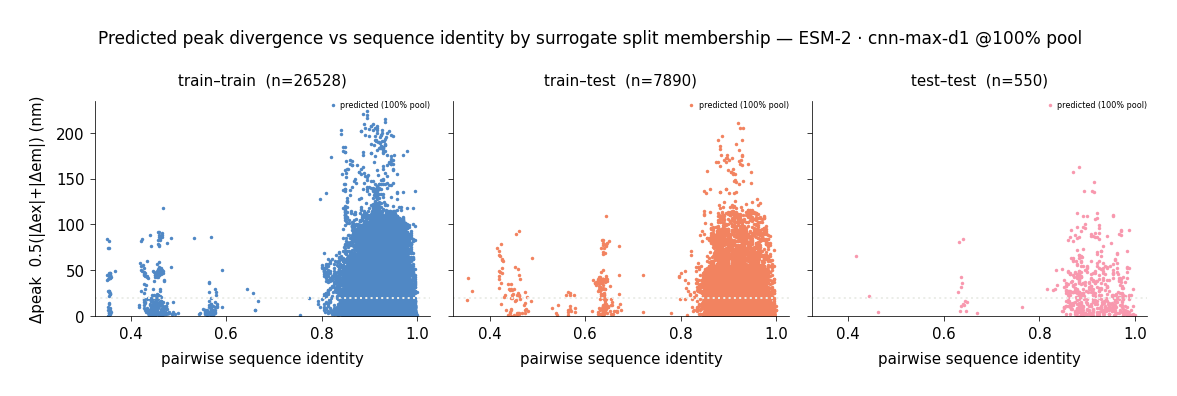

In [5]:
from scipy.stats import spearmanr
# reload the §1 surrogate model trained on 100% of its fixed train pool (cnn-max-d1, seed 0) — top of the curve
FULL_ROLE="surrogate"; FULL_SEED=0; FULL_TAG=ROLE_EMB[FULL_ROLE]; Dfull=DATA[FULL_ROLE]
LC_MODEL=lc_model_path(FULL_ROLE,1.0,FULL_SEED)
PRED100_CACHE=f"trained_models/pred_100pool_{FULL_ROLE}.npz"     # per-FP peak predictions of that model
def _predict_all(net):
    net.eval(); ps=[]
    with torch.no_grad():
        for Hb,mk,b in swp.batches(Dfull, np.arange(N), dev): ps.append(net(Hb,mk).cpu().numpy())
    return np.concatenate(ps)
if os.path.exists(PRED100_CACHE):
    P100=np.load(PRED100_CACHE)["P"]
    print(f"loaded 100%-pool predictions: {PRED100_CACHE}")
else:
    if not os.path.exists(LC_MODEL):                             # §1 not run yet -> train just this one fit
        D2=subset_D(Dfull, Dfull["tr"])
        m,base=swp.train_eval(BEST[FULL_ROLE], FULL_SEED, D2, dev, EPOCHS, PATIENCE)
        pm.save_model(LC_MODEL, base, {**BEST[FULL_ROLE],"d_in":Dfull["d_in"],"out":2,"seed":FULL_SEED,
                                       "role":FULL_ROLE,"emb":Dfull["emb"],"mean":D2["mean"],"std":D2["std"],
                                       "n_train":int(len(Dfull["tr"])),**m})
        print(f"§1 checkpoint missing -> trained {swp.label(BEST[FULL_ROLE])} on 100% pool (n_train={len(Dfull['tr'])})")
    base,ck=pm.load_model(LC_MODEL, dev); net=pm.wrap(base, ck["mean"], ck["std"], dev)
    P100=_predict_all(net); np.savez(PRED100_CACHE, P=P100)
    print(f"reloaded §1 model {LC_MODEL} (n_train={ck.get('n_train')}) and cached predictions: {PRED100_CACHE}")

# identity-aligned pairs (similarity) from §3, predicted vs true peak distance
GT_CACHE="trained_models/similarity_deltapeak_truth.npz"
_gt=np.load(GT_CACHE); Ai,Bi,pid,dpk=_gt["Ai"],_gt["Bi"],_gt["pid"],_gt["dpk"]
dp_pred=0.5*(np.abs(P100[Ai,0]-P100[Bi,0])+np.abs(P100[Ai,1]-P100[Bi,1]))
is_test=np.zeros(N,bool); is_test[Dfull["te"]]=True             # split membership from the surrogate role's fixed test set
groups={"train–train":(~is_test[Ai])&(~is_test[Bi]),
        "train–test":(is_test[Ai]^is_test[Bi]),
        "test–test":(is_test[Ai])&(is_test[Bi])}
GCOL={"train–train":C("aegean"),"train–test":C("amber"),"test–test":C("rose")}
be=np.linspace(0.6,1.0,9); ct=0.5*(be[:-1]+be[1:]); ymax=float(max(dpk.max(),dp_pred.max()))*1.05
fig,axes=plt.subplots(1,3,figsize=(16,5),sharex=True,sharey=True)
print("group        n_pairs  medΔpred  medΔtrue  med|Δpred-Δtrue|  rho(id,Δpred)")
for ax,(name,m) in zip(axes,groups.items()):
    idx=np.where(m)[0]
    rho=spearmanr(pid[idx],dp_pred[idx])[0] if len(idx)>2 else np.nan
    err=np.median(np.abs(dp_pred[idx]-dpk[idx])) if len(idx) else np.nan
    print(f"  {name:11} {len(idx):7d}  {np.median(dp_pred[idx]):7.1f}  {np.median(dpk[idx]):7.1f}  {err:14.1f}  {rho:.2f}")
    #ax.scatter(pid[idx],dpk[idx],s=10,alpha=0.12,color=C("gray"),label="ground truth")
    ax.scatter(pid[idx],dp_pred[idx],s=12,alpha=1,color=GCOL[name],label="predicted (100% pool)")
    mdp=[np.median(dp_pred[idx][(pid[idx]>=be[i])&(pid[idx]<be[i+1])]) if ((pid[idx]>=be[i])&(pid[idx]<be[i+1])).any() else np.nan for i in range(8)]
    #ax.plot(ct,mdp,"-o",color=GCOL[name],lw=2)
    ax.axhline(20,ls=":",color=C("gray"))
    ax.set_xlabel("pairwise sequence identity"); ax.set_ylim(0,ymax)
    ax.set_title(f"{name}  (n={len(idx)})"); ax.legend(fontsize=8)
axes[0].set_ylabel("Δpeak  0.5(|Δex|+|Δem|) (nm)")
plt.suptitle(f"Predicted peak divergence vs sequence identity by {FULL_ROLE} split membership — {FULL_TAG} @100% pool")
plt.tight_layout(); fig.savefig("trained_models/pairsim_by_split_100pool.png",dpi=130,bbox_inches="tight"); plt.show()

group        n_pairs  med|Δpred-Δtrue|  spearman  pearson    R2
  train–train   26528             4.0     0.92     0.92   0.84
  train–test     7890             7.3     0.76     0.75   0.53
  test–test       550             9.6     0.59     0.62   0.27


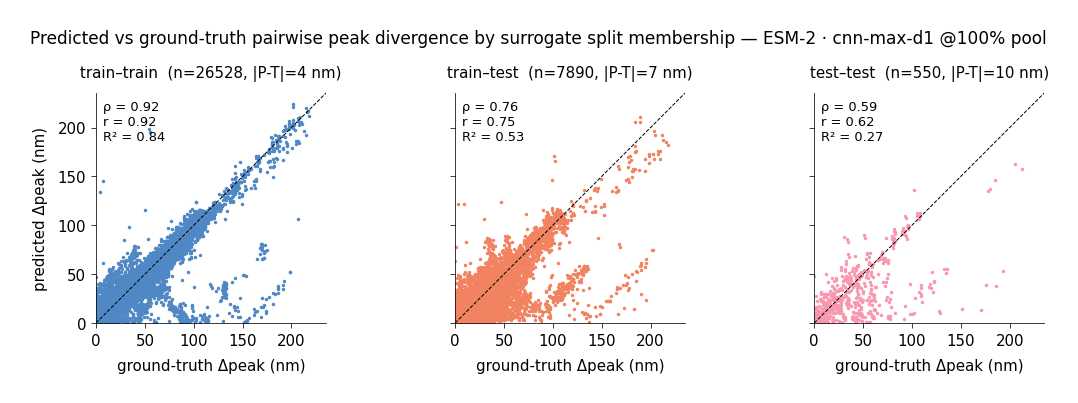

In [6]:
# predicted vs ground-truth pairwise Δpeak (same 100%-pool cnn-max), split by 85/15 membership
from scipy.stats import pearsonr
lim=float(max(dpk.max(),dp_pred.max()))*1.05
fig,axes=plt.subplots(1,3,figsize=(16,5),sharex=True,sharey=True)
print("group        n_pairs  med|Δpred-Δtrue|  spearman  pearson    R2")
for ax,(name,m) in zip(axes,groups.items()):
    idx=np.where(m)[0]
    err=np.median(np.abs(dp_pred[idx]-dpk[idx])) if len(idx) else np.nan
    rho=spearmanr(dpk[idx],dp_pred[idx])[0] if len(idx)>2 else np.nan
    r=pearsonr(dpk[idx],dp_pred[idx])[0] if len(idx)>2 else np.nan
    r2=1-np.sum((dp_pred[idx]-dpk[idx])**2)/np.sum((dpk[idx]-dpk[idx].mean())**2) if len(idx)>1 else np.nan
    print(f"  {name:11} {len(idx):7d}  {err:14.1f}  {rho:7.2f}  {r:7.2f}  {r2:5.2f}")
    ax.plot([0,lim],[0,lim],ls="--",color=C("black"),lw=1,label="y = x")
    ax.scatter(dpk[idx],dp_pred[idx],s=12,alpha=1,color=GCOL[name])
    ax.text(0.03,0.97,f"ρ = {rho:.2f}\nr = {r:.2f}\nR² = {r2:.2f}",transform=ax.transAxes,va="top",ha="left",fontsize=13)
    ax.set_xlabel("ground-truth Δpeak (nm)"); ax.set_xlim(0,lim); ax.set_ylim(0,lim)
    ax.set_title(f"{name}  (n={len(idx)}, |P-T|={err:.0f} nm)"); #ax.legend(fontsize=8)
    ax.set_box_aspect(1)
axes[0].set_ylabel("predicted Δpeak (nm)")
plt.suptitle(f"Predicted vs ground-truth pairwise peak divergence by {FULL_ROLE} split membership — {FULL_TAG} @100% pool")
plt.tight_layout(); fig.savefig("trained_models/pairdiff_pred_vs_truth_100pool.png",dpi=130,bbox_inches="tight"); plt.show()

test–test: median GT=33.8 nm | median pred=23.0 nm | median(pred−GT)=-1.5 nm | Wilcoxon p=7.98e-09


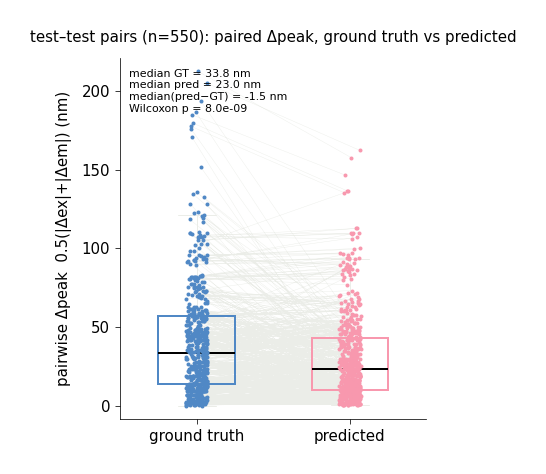

In [7]:
# test–test pairs: paired Δpeak (ground truth vs predicted), same 100%-pool cnn-max
from scipy.stats import wilcoxon
idx=np.where(groups["test–test"])[0]; gt=dpk[idx]; pr=dp_pred[idx]
jit=(np.random.default_rng(0).random(len(idx))-0.5)*0.14
x1=1.0+jit; x2=2.0+jit
fig,ax=plt.subplots(figsize=(5.6,6.2))
segx=np.column_stack([x1,x2,np.full(len(idx),np.nan)]).ravel()      # one artist for all pair-connectors
segy=np.column_stack([gt,pr,np.full(len(idx),np.nan)]).ravel()
ax.plot(segx,segy,color=C("gray"),lw=0.4,alpha=1,zorder=1)
ax.scatter(x1,gt,s=16,alpha=1,color=C("aegean"),zorder=3,label="ground truth")
ax.scatter(x2,pr,s=16,alpha=1,color=C("rose"),zorder=3,label="predicted (100% pool)")
bp=ax.boxplot([gt,pr],positions=[1,2],widths=0.5,showfliers=False,patch_artist=True,zorder=2)
for patch,cc in zip(bp["boxes"],[C("aegean"),C("rose")]): patch.set(facecolor="none",edgecolor=cc,linewidth=2)
for med in bp["medians"]: med.set(color="black",linewidth=2)
for wh in bp["whiskers"]+bp["caps"]: wh.set(color=C("gray"))
ax.set_xticks([1,2]); ax.set_xticklabels(["ground truth","predicted"]); ax.set_xlim(0.5,2.5)
ax.set_ylabel("pairwise Δpeak  0.5(|Δex|+|Δem|) (nm)")
ax.set_title(f"test–test pairs (n={len(idx)}): paired Δpeak, ground truth vs predicted")
W,pval=wilcoxon(pr,gt)
ax.text(0.03,0.97,f"median GT = {np.median(gt):.1f} nm\nmedian pred = {np.median(pr):.1f} nm\nmedian(pred−GT) = {np.median(pr-gt):.1f} nm\nWilcoxon p = {pval:.1e}",
        transform=ax.transAxes,va="top",ha="left",fontsize=11)
print(f"test–test: median GT={np.median(gt):.1f} nm | median pred={np.median(pr):.1f} nm | median(pred−GT)={np.median(pr-gt):.1f} nm | Wilcoxon p={pval:.2e}")
plt.tight_layout(); fig.savefig("trained_models/testtest_paired_deltapeak.png",dpi=130,bbox_inches="tight"); plt.show()

## Notes
- This is a **data** learning curve (test error vs training-set size), distinct from the per-epoch curve.
  Each role keeps its **fixed** train/val/test split (`dual_splits.csv`) — only the size of the training
  subset drawn from that fixed train pool changes, so points are comparable.
- Two winners, each on its own embedding + split: **surrogate** `cnn-max-d1` (ESM-2, surrogate split) and
  **oracle** `cnn-max-d2` (ProstT5, oracle split). Fractions **10 / 20 / 50 / 80 / 100%** of each train pool;
  same protocol as the sweep (early stopping on the fixed val set, max 100 epochs / patience 10). Bands are
  ±1 std over 3 random subset draws per size.
- A still-falling test curve at 100% ⇒ more data would help; a flattening curve ⇒ data-limited returns.
- §3 ruggedness is a **data-landscape** diagnostic (model-free): peak divergence vs sequence identity among
  near-duplicate FP pairs. High-identity median = intrinsic floor; fat upper tail = spectral cliffs.
- §1 caches every fit to `trained_models/lc_models/<role>_<label>_p<frac>_s<seed>.pt`; §4 **reloads** the
  surrogate 100%-pool model (seed 0) and plots predicted Δpeak vs sequence identity split by surrogate-split
  membership (train–train / train–test / test–test).